In [2]:
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

/home/mushu/GitHub/IML-Coursework/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load FashionMNIST

In [3]:
print("Loading FashionMNIST...")
fmnist = load_dataset('fashion_mnist')

def extract(split, n=None):
    """Return (X, y) as float32 numpy arrays. X is normalised to [0,1]."""
    data = fmnist[split]
    if n is not None:
        data = data.select(range(n))
    # Each 'image' is a PIL Image; convert via numpy
    images = np.array([np.array(img).flatten() for img in data['image']], dtype=np.float32)
    images /= 255.0
    labels = np.array(data['label'], dtype=np.int32)
    return images, labels

# Use 10 000 training samples to keep runtime reasonable for a naive implementation
X_train, y_train = extract('train', n=10000)
X_test,  y_test  = extract('test')

print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print(f"Labels: {np.unique(y_train)}")

Loading FashionMNIST...


Train: (10000, 784),  Test: (10000, 784)
Labels: [0 1 2 3 4 5 6 7 8 9]


In [4]:
def softmax(z):
    """Numerically stable softmax. z shape: (n, C)."""
    z_shifted = z - z.max(axis=1, keepdims=True)
    exp_z = np.exp(z_shifted)
    return exp_z / exp_z.sum(axis=1, keepdims=True)


def one_hot(y, n_classes=10):
    """Return one-hot matrix of shape (n, n_classes)."""
    n = len(y)
    oh = np.zeros((n, n_classes), dtype=np.float32)
    oh[np.arange(n), y] = 1.0
    return oh


def cross_entropy_loss(probs, y):
    """Mean cross-entropy loss. probs: (n, C), y: (n,) integer labels."""
    n = len(y)
    # Clip to avoid log(0)
    correct_probs = probs[np.arange(n), y].clip(1e-12, 1.0)
    return -np.mean(np.log(correct_probs))


def compute_gradients(X, probs, y):
    """Return grad_W, grad_b."""
    n = len(y)
    delta = probs - one_hot(y)   # (n, C)
    grad_W = X.T @ delta / n     # (784, C)
    grad_b = delta.mean(axis=0)  # (C,)
    return grad_W, grad_b


def accuracy(probs, y):
    return np.mean(probs.argmax(axis=1) == y)


print("Helper functions defined.")

Helper functions defined.


## 3. Gradient Descent Training

In [5]:
np.random.seed(0)
n_classes = 10
n_features = X_train.shape[1]   # 784

# Initialise weights small
W = np.random.randn(n_features, n_classes).astype(np.float32) * 0.01
b = np.zeros(n_classes, dtype=np.float32)

# Hyperparameters
lr      = 0.4     # learning rate
n_iters = 2000     # gradient descent iterations

train_losses = []
test_accs    = []

for i in range(n_iters):
    # Forward pass
    logits = X_train @ W + b         # (n, 10)
    probs  = softmax(logits)

    # Loss
    loss = cross_entropy_loss(probs, y_train)
    train_losses.append(loss)

    # Gradients
    grad_W, grad_b = compute_gradients(X_train, probs, y_train)

    # Update
    W -= lr * grad_W
    b -= lr * grad_b

    # Test accuracy every 20 steps
    if (i + 1) % 20 == 0:
        test_logits = X_test @ W + b
        test_probs  = softmax(test_logits)
        acc = accuracy(test_probs, y_test)
        test_accs.append(acc)
        print(f"Iter {i+1:4d} | Loss: {loss:.4f} | Test Acc: {acc*100:.2f}%")

print("\nTraining complete.")

Iter   20 | Loss: 1.8431 | Test Acc: 56.61%
Iter   40 | Loss: 1.5759 | Test Acc: 69.85%
Iter   60 | Loss: 1.0798 | Test Acc: 71.40%
Iter   80 | Loss: 0.8051 | Test Acc: 71.57%
Iter  100 | Loss: 1.2402 | Test Acc: 73.18%
Iter  120 | Loss: 0.8608 | Test Acc: 71.82%
Iter  140 | Loss: 0.9985 | Test Acc: 77.37%
Iter  160 | Loss: 1.1459 | Test Acc: 77.88%
Iter  180 | Loss: 0.8611 | Test Acc: 75.43%
Iter  200 | Loss: 1.0846 | Test Acc: 78.12%
Iter  220 | Loss: 0.5872 | Test Acc: 79.69%
Iter  240 | Loss: 0.6544 | Test Acc: 78.74%
Iter  260 | Loss: 0.6106 | Test Acc: 78.14%
Iter  280 | Loss: 1.0307 | Test Acc: 78.51%
Iter  300 | Loss: 0.8768 | Test Acc: 78.42%
Iter  320 | Loss: 0.7555 | Test Acc: 78.40%
Iter  340 | Loss: 0.6372 | Test Acc: 79.57%
Iter  360 | Loss: 0.6049 | Test Acc: 80.03%
Iter  380 | Loss: 0.6136 | Test Acc: 79.91%
Iter  400 | Loss: 0.5922 | Test Acc: 80.28%
Iter  420 | Loss: 0.5677 | Test Acc: 80.62%
Iter  440 | Loss: 0.6910 | Test Acc: 77.59%
Iter  460 | Loss: 0.7363 | Test 

## 4. Final Evaluation on Test Set

In [6]:
test_logits = X_test @ W + b
test_probs  = softmax(test_logits)
final_acc   = accuracy(test_probs, y_test)

print(f"Final Test Accuracy: {final_acc * 100:.2f}%")

# Class names for FashionMNIST
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Per-class accuracy
preds = test_probs.argmax(axis=1)
print("\nPer-class accuracy:")
for c in range(n_classes):
    mask = y_test == c
    cls_acc = np.mean(preds[mask] == c)
    print(f"  {class_names[c]:15s}: {cls_acc*100:.1f}%")

Final Test Accuracy: 80.83%

Per-class accuracy:
  T-shirt/top    : 89.1%
  Trouser        : 96.0%
  Pullover       : 56.3%
  Dress          : 81.0%
  Coat           : 92.7%
  Sandal         : 89.8%
  Shirt          : 20.9%
  Sneaker        : 93.3%
  Bag            : 95.4%
  Ankle boot     : 93.8%


## 5. Training Curve

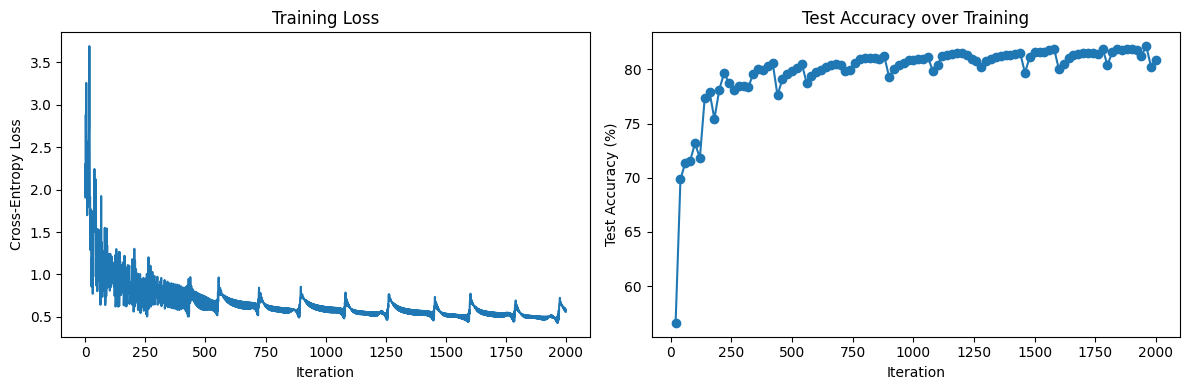

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss')

axes[1].plot(range(20, n_iters + 1, 20), [a * 100 for a in test_accs], marker='o')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy over Training')

plt.tight_layout()
plt.savefig('q2_training_curve.png', dpi=100)
plt.show()